#### Загрузка данных и пакетов

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
print(df.shape)
print(df.head())
print(df.info())

(41157, 6)
   UserName  ScreenName   Location     TweetAt  \
0      3799       48751     London  16-03-2020   
1      3800       48752         UK  16-03-2020   
2      3801       48753  Vagabonds  16-03-2020   
3      3802       48754        NaN  16-03-2020   
4      3803       48755        NaN  16-03-2020   

                                       OriginalTweet           Sentiment  
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...             Neutral  
1  advice Talk to your neighbours family to excha...            Positive  
2  Coronavirus Australia: Woolworths to give elde...            Positive  
3  My food stock is not the only one which is emp...            Positive  
4  Me, ready to go at supermarket during the #COV...  Extremely Negative  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 

In [3]:
df["Sentiment"].value_counts()

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64

In [6]:
df["Sentiment"] = df["Sentiment"].replace('Extremely Negative', 'Negative')
df["Sentiment"] = df["Sentiment"].replace('Extremely Positive', 'Positive')

In [7]:
df["Sentiment"].value_counts()

Sentiment
Positive    18046
Negative    15398
Neutral      7713
Name: count, dtype: int64

#### Вывод случайных значений

In [8]:
df.sample(10, random_state=42)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
31089,34888,79840,Lagos,06-04-2020,Without the there would not be any problem wh...,Neutral
35564,39363,84315,NaN,09-04-2020,Rice &amp; wheat prices surge amid fears Covid...,Negative
144,3943,48895,NaN,16-03-2020,When the government says to start social dista...,Positive
8202,12001,56953,irlande du nord,19-03-2020,What the shops are doing is obeying the law of...,Positive
31720,35519,80471,"Zaria, Nigeria",07-04-2020,Kaduna State Task Force on Covid 19 led by the...,Negative
25367,29166,74118,"Dallas, TX",31-03-2020,No #coronavirus break for consumer credit scor...,Positive
29772,33571,78523,"Hatfield, UK",05-04-2020,@dreamy_blue WeÂre working closely with suppl...,Positive
12574,16373,61325,Las Vegas,21-03-2020,My sister works at a grocery store. Those empl...,Negative
28059,31858,76810,"Ngong, Kenya",04-04-2020,The Tuskys supermarket has partnered with loca...,Neutral
12471,16270,61222,Cape Verde,21-03-2020,Does anyone know about a way of getting food d...,Positive


In [9]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df = df[['OriginalTweet', 'Sentiment']]
print(df.head(10))

                                       OriginalTweet Sentiment
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...   Neutral
1  advice Talk to your neighbours family to excha...  Positive
2  Coronavirus Australia: Woolworths to give elde...  Positive
3  My food stock is not the only one which is emp...  Positive
4  Me, ready to go at supermarket during the #COV...  Negative
5  As news of the regionÂs first confirmed COVID...  Positive
6  Cashier at grocery store was sharing his insig...  Positive
7  Was at the supermarket today. Didn't buy toile...   Neutral
8  Due to COVID-19 our retail store and classroom...  Positive
9  For corona prevention,we should stop to buy th...  Negative


#### Визуализация

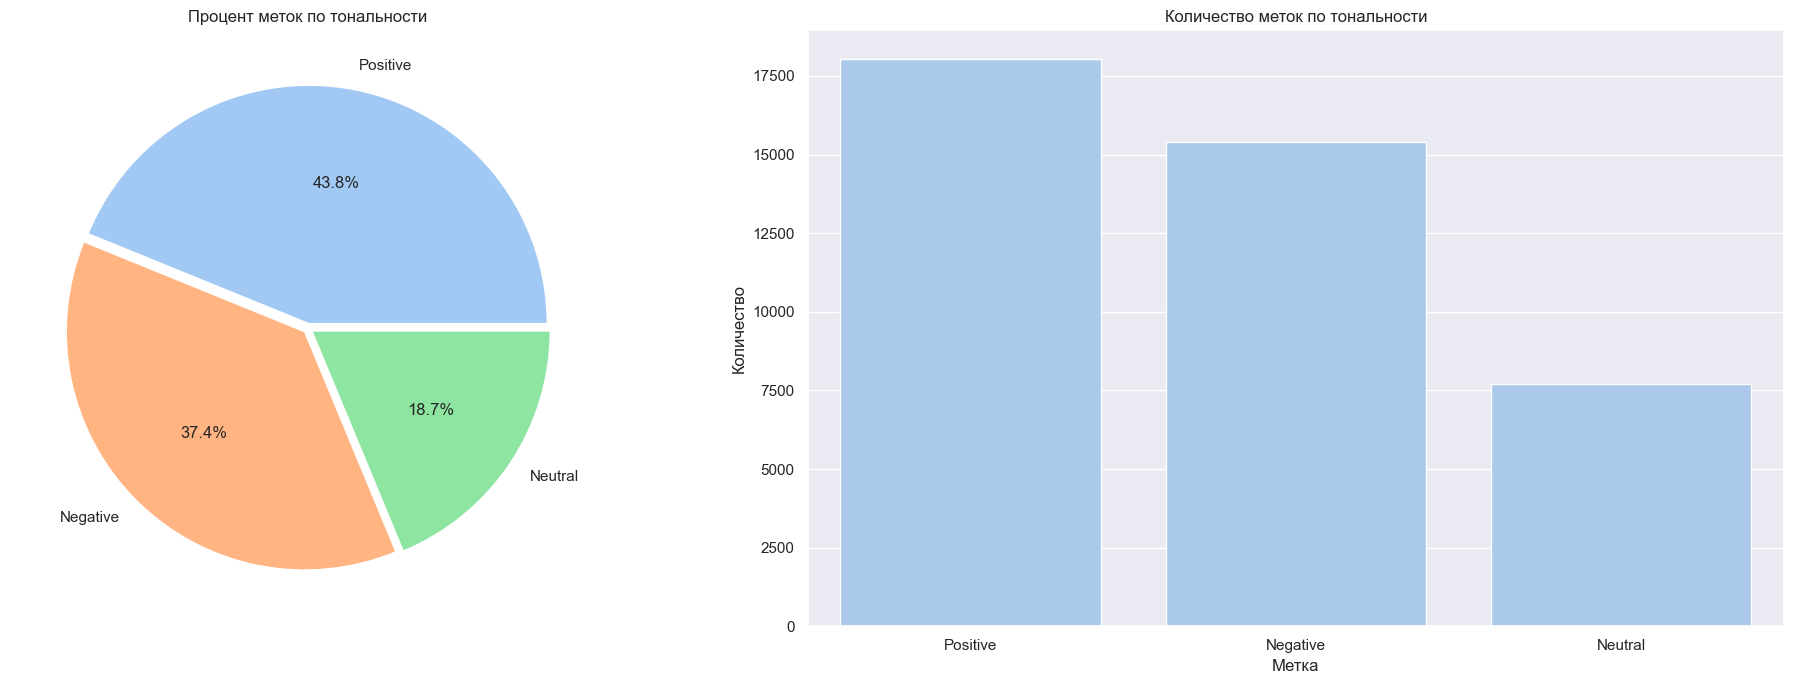

In [16]:
label_count = df['Sentiment'].value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (20, 7))
sns.set_theme(style='darkgrid', palette='pastel')
color = sns.color_palette(palette='pastel')
explode = [0.02]*len(label_count)

axes[0].pie(label_count.values, labels=label_count.index, autopct='%1.1f%%', explode=explode)
axes[0].set_title('Процент меток по тональности')

sns.barplot(y=label_count.values, x=label_count.index)
axes[1].set_title('Количество меток по тональности')
axes[1].set_xlabel('Метка')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()